# **Deskripsi Dataset**

Dataset yang digunakan merupakan gambaran tentang mahasiswa yang terdaftar dalam 
berbagai program sarjana yang ditawarkan oleh perguruan tinggi. Data ini mencakup data 
demografis, faktor sosial-ekonomi, dan informasi kinerja akademik yang dapat digunakan 
untuk menganalisis faktor-faktor yang mungkin memprediksi tingkat kesuksesan akademik 
mahasiswa.

# **Requirements and Config**

In [48]:
# !pip install seaborn matplotlib numpy pandas

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.getcwd())
from allyouneed.base import BaseEstimator, TransformerMixin
from allyouneed.tree import DecisionTreeClassifier
from allyouneed.model_selection import StratifiedKFold
from allyouneed.metrics import Accuracy, F1Score
from allyouneed.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler
from allyouneed.feature_selection import ForwardFeatureSelection, BackwardFeatureElimination

# Benchmark models from sklearn
from sklearn.tree import DecisionTreeClassifier as SklearnDecisionTreeClassifier
from sklearn.svm import SVC as SklearnSVC
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression

import warnings
warnings.filterwarnings("ignore")


pd.set_option('display.max_columns', None)

class settings:
    DATA_DIR = "../dataset/"
    TRAIN_FILE = "train.csv"
    TEST_FILE = "test.csv"
    SUBMISSION_FILE = "sample_submission.csv"
    INDEX_COL = "Student_ID"
    SEED = 42
    TARGET = "Target"
    TRAIN_PATH = DATA_DIR + TRAIN_FILE
    TEST_PATH = DATA_DIR + TEST_FILE
    SUBMISSION_PATH = DATA_DIR + SUBMISSION_FILE

In [50]:
train = pd.read_csv(settings.TRAIN_PATH, index_col=settings.INDEX_COL)
test = pd.read_csv(settings.TEST_PATH, index_col=settings.INDEX_COL)
submission = pd.read_csv(settings.SUBMISSION_PATH, index_col=settings.INDEX_COL)
train.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
Student_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3743,1,17,1,9670,1,1,118.0,1,19,38,7,9,113.5,1,0,0,1,0,1,19,0,0,6,9,5,13.500000,0,0,6,6,6,14.000000,0,12.4,0.5,1.79,Graduate
3540,1,1,1,9070,1,1,139.0,1,1,19,3,9,134.9,1,0,0,1,1,0,20,0,0,6,7,6,13.666667,0,0,6,7,6,12.166667,1,16.2,0.3,-0.92,Graduate
1118,1,1,1,9500,1,1,138.0,1,38,19,9,5,144.3,0,0,0,1,0,0,20,0,0,7,9,6,12.700000,0,0,8,8,7,13.571429,0,13.9,-0.3,0.79,Graduate
791,1,17,1,9773,1,1,138.0,1,1,19,9,9,124.0,0,0,0,1,0,1,19,0,0,6,6,6,13.166667,0,0,6,6,6,13.833333,0,11.1,0.6,2.02,Graduate
4381,1,7,1,9500,1,2,140.0,1,38,37,7,8,140.0,0,0,0,1,0,0,29,0,0,8,14,4,11.325000,1,0,8,14,4,11.325000,1,12.7,3.7,-1.70,Dropout


# **Exploratory Data Analysis**

In [51]:
# 1. Pilih kolom int64
int_cols = train.select_dtypes(include="int64").columns

# 2. Salinan agar tidak mengubah train asli
df_cat = train[int_cols].copy()

# 3. Convert semua kolom int ke categorical (object)
df_cat = df_cat.astype("object")

# 4. Hitung nunique dan mode
summary = []

for col in df_cat.columns:
    nunique = df_cat[col].nunique()
    mode = df_cat[col].mode().iloc[0] if nunique > 0 else None
    summary.append({
        "column": col,
        "nunique": nunique,
        "mode": mode
    })

summary_df = pd.DataFrame(summary)

summary_df.loc[summary_df['nunique'] > 2].column.values

array(['Marital status', 'Application mode', 'Application order',
       'Course', 'Previous qualification', 'Nacionality',
       "Mother's qualification", "Father's qualification",
       "Mother's occupation", "Father's occupation", 'Age at enrollment',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (without evaluations)'], dtype=object)

<Axes: >

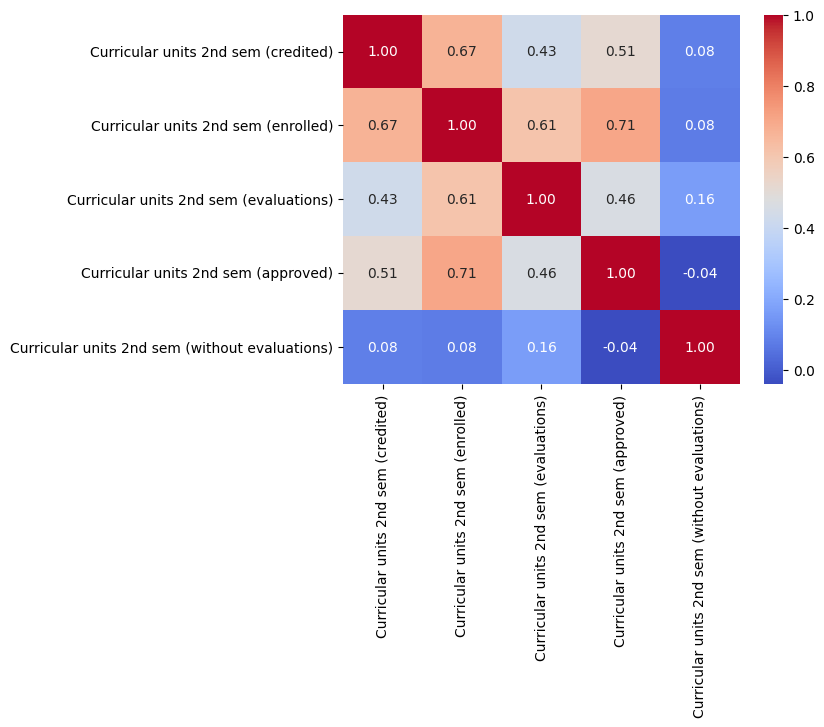

In [52]:
sns.heatmap(train[['Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (without evaluations)']].select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f", cmap="coolwarm")

# **Preprocessing**

## **Data Cleaning**

In [53]:
def drop_columns(df):
    col = []
    return df.drop(columns=col)

## **Data Transformation**

In [54]:
label_encoder = LabelEncoder()
label_encoder.fit(train[settings.TARGET])

def add_semester2_features(df):
    df = df.copy()

    # Hindari pembagian dengan 0
    enrolled_2 = df["Curricular units 2nd sem (enrolled)"].replace(0, np.nan)
    evaluations_2 = df["Curricular units 2nd sem (evaluations)"].replace(0, np.nan)

    # 1. Completion Ratio: approved / enrolled
    # df["sem2_ratio_approved"] = df["Curricular units 2nd sem (approved)"] / enrolled_2

    # 2. Evaluation Participation: evaluations / enrolled
    df["sem2_ratio_evaluated"] = df["Curricular units 2nd sem (evaluations)"] / enrolled_2

    # 3. Absenteeism: without evaluations / enrolled
    df["sem2_ratio_absent"] = df["Curricular units 2nd sem (without evaluations)"] / enrolled_2

    # 4. Credit Efficiency: credited / enrolled
    df["sem2_credit_efficiency"] = df["Curricular units 2nd sem (credited)"] / enrolled_2

    # 5. Evaluation Efficiency: approved / evaluations
    df["sem2_evaluation_efficiency"] = df["Curricular units 2nd sem (approved)"] / evaluations_2

    # 6. Load Gap: enrolled - credited
    df["sem2_load_gap"] = df["Curricular units 2nd sem (enrolled)"] - df["Curricular units 2nd sem (credited)"]

    # 7. Study Dedication Score (composite)
    df["sem2_study_dedication"] = (
        df["Curricular units 2nd sem (credited)"]
        - df["Curricular units 2nd sem (without evaluations)"]
        + df["Curricular units 2nd sem (approved)"]
    )

    # 8. Risk Score (composite)
    df["sem2_risk_score"] = (
        df["Curricular units 2nd sem (without evaluations)"]
        + (df["Curricular units 2nd sem (enrolled)"] - df["Curricular units 2nd sem (approved)"])
    )

    return df

def add_semester1_features(df):
    df = df.copy()

    # Avoid division by 0
    enrolled_1 = df["Curricular units 1st sem (enrolled)"].replace(0, np.nan)
    evaluations_1 = df["Curricular units 1st sem (evaluations)"].replace(0, np.nan)

    # 1. Completion Ratio: approved / enrolled
    # df["sem1_ratio_approved"] = df["Curricular units 1st sem (approved)"] / enrolled_1

    # 2. Evaluation Participation Ratio: evaluations / enrolled
    df["sem1_ratio_evaluated"] = df["Curricular units 1st sem (evaluations)"] / enrolled_1

    # 3. Absenteeism: without evaluations / enrolled
    df["sem1_ratio_absent"] = df["Curricular units 1st sem (without evaluations)"] / enrolled_1

    # 4. Credit Efficiency: credited / enrolled
    df["sem1_credit_efficiency"] = df["Curricular units 1st sem (credited)"] / enrolled_1

    # 5. Evaluation Efficiency: approved / evaluations
    df["sem1_evaluation_efficiency"] = df["Curricular units 1st sem (approved)"] / evaluations_1

    # 6. Load Gap: enrolled - credited
    df["sem1_load_gap"] = (
        df["Curricular units 1st sem (enrolled)"] -
        df["Curricular units 1st sem (credited)"]
    )

    # 7. Study Dedication Score (composite)
    df["sem1_study_dedication"] = (
        df["Curricular units 1st sem (credited)"]
        - df["Curricular units 1st sem (without evaluations)"]
        + df["Curricular units 1st sem (approved)"]
    )

    # 8. Risk Score (composite)
    df["sem1_risk_score"] = (
        df["Curricular units 1st sem (without evaluations)"] +
        (df["Curricular units 1st sem (enrolled)"] - df["Curricular units 1st sem (approved)"])
    )

    return df



## **Feature Selection**

## **Dimensionality Reduction**

## **Pipeline**

In [55]:
# !pip install scikit-learn

In [68]:
class Preprocessing(BaseEstimator, TransformerMixin):
    def __init__(self, categorical_cols=None, dropped_cols=None, z_threshold=1.9):
        self.categorical_cols = categorical_cols or []
        self.dropped_cols = dropped_cols or []
        self.ohe = OneHotEncoder(columns=self.categorical_cols, dtype=float)
        self.scaler = StandardScaler()
        self.numeric_cols = []
        self.fitted = False
        
        # --- Z-score parameters ---
        self.z_threshold = z_threshold
        self.zscore_params = {}

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("X must be a pandas DataFrame")

        if self.dropped_cols:
            X = X.drop(columns=self.dropped_cols)

        self.numeric_cols = (
            X.select_dtypes(include=[np.number])
             .columns
             .difference(self.categorical_cols)
             .tolist()
        )

        # --- Hitung mean & std untuk Z-score clipping ---
        self.zscore_params = {}
        for col in self.numeric_cols:
            mean = X[col].mean()
            std = X[col].std()
            self.zscore_params[col] = (mean, std)

        self.ohe.fit(X)
        self.scaler.fit(X[self.numeric_cols])

        self.fitted = True
        return self

    def transform(self, X):
        if not self.fitted:
            raise ValueError("Preprocessing must be fitted before transform()")

        if self.dropped_cols:
            X = X.drop(columns=self.dropped_cols)

        X_num = X[self.numeric_cols].astype(float)

        # --- Z-score clipping ---
        for col in self.numeric_cols:
            mean, std = self.zscore_params[col]
            z = (X_num[col] - mean) / std
            z = z.clip(-self.z_threshold, self.z_threshold)
            X_num[col] = z * std + mean

        # Categorical
        X_cat_array = self.ohe.transform(X)
        X_cat = pd.DataFrame(
            X_cat_array,
            columns=self.ohe.feature_names_,
            index=X.index
        )

        # Scaling
        X_num_scaled = self.scaler.transform(X_num)
        X_num = pd.DataFrame(X_num_scaled, columns=self.numeric_cols, index=X.index)

        return pd.concat([X_num, X_cat], axis=1)



CATEGORICAL_COLS = [
    'Marital status', 
    'Application mode', 
       'Course', 
    #    'Previous qualification', 
       'Nacionality',
    #    "Mother's qualification", 
    # "Father's qualification",
       "Mother's occupation", 
       "Father's occupation"
       ]

DROPPED_COLS = [
"Mother's qualification", "Father's qualification"
]

preprocessor = Preprocessing(categorical_cols=CATEGORICAL_COLS, dropped_cols=DROPPED_COLS)
X_train, y_train = train.drop(columns=[settings.TARGET]), label_encoder.transform(train[settings.TARGET])
X_train = preprocessor.fit_transform(X_train)
y_train = label_encoder.transform(train[settings.TARGET])


ffs = ForwardFeatureSelection(
    estimator=SklearnDecisionTreeClassifier(criterion='gini'),
    n_features_to_select=100,
    scoring=F1Score(average='macro'),
    verbose=True,
    feature_names=X_train.columns.tolist(),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=settings.SEED),
)

In [57]:
ffs.fit(X_train, y_train)
# ffs.selected_features_

Forward Feature Selection
Total features: 157
Target features: 100

Iteration 1/100
Testing 157 features...
Selected: Curricular units 2nd sem (approved) (score: 0.6134)
Current features: ['Curricular units 2nd sem (approved)']

Iteration 2/100
Testing 156 features...
Selected: Mother's occupation__5 (score: 0.6361)
Current features: ['Curricular units 2nd sem (approved)', "Mother's occupation__5"]

Iteration 3/100
Testing 155 features...
Selected: Tuition fees up to date (score: 0.6490)
Current features: ['Curricular units 2nd sem (approved)', "Mother's occupation__5", 'Tuition fees up to date']

Iteration 4/100
Testing 154 features...
Selected: Mother's occupation__0 (score: 0.6637)
Current features: ['Curricular units 2nd sem (approved)', "Mother's occupation__5", 'Tuition fees up to date', "Mother's occupation__0"]

Iteration 5/100
Testing 153 features...
Selected: Course__9500 (score: 0.6710)
Current features: ['Curricular units 2nd sem (approved)', "Mother's occupation__5", 'Tuit

# **Modeling and Validation**

## **Metrics**

In [58]:
# ============================================================
# Utility: Confusion Matrix
# ============================================================
class ConfusionMatrix:
    """
    Computes confusion matrix using NumPy.
    """

    def __call__(self, y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)

        labels = np.unique(np.concatenate([y_true, y_pred]))
        label_to_idx = {label: idx for idx, label in enumerate(labels)}
        
        cm = np.zeros((len(labels), len(labels)), dtype=int)

        for t, p in zip(y_true, y_pred):
            cm[label_to_idx[t], label_to_idx[p]] += 1
        
        return cm, labels

# ============================================================
# Metric Collection (Run multiple metrics at once)
# ============================================================
class MetricCollection:
    """
    Utility to compute multiple metrics at once.
    """

    def __init__(self, metrics: dict):
        """
        metrics: dict[name -> Metric instance]
        """
        self.metrics = metrics

    def __call__(self, y_true, y_pred):
        return {name: metric(y_true, y_pred) for name, metric in self.metrics.items()}


## **Modeling**

In [59]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=settings.SEED)

models = {
    'DT': DecisionTreeClassifier(random_state=settings.SEED),
}

metrics = MetricCollection({
    'accuracy': Accuracy(),
    'f1_macro': F1Score(average='macro'),
    'f1_micro': F1Score(average='micro'),
    'f1_weighted': F1Score(average='weighted')  
})

all_results = {} 

In [60]:


for name, model in models.items():
    print(f"Training model: {name}")
    fold_results = []  # store metric dict for each fold

    for fold, (train_idx, val_idx) in enumerate(skf.split(train, train[settings.TARGET])):
        
        # -------------------------
        # Split data
        # -------------------------
        X_train = train.drop(columns=[settings.TARGET]).iloc[train_idx]
        y_train_raw = train[settings.TARGET].iloc[train_idx].values
        y_train = label_encoder.transform(y_train_raw)

        X_val = train.drop(columns=[settings.TARGET]).iloc[val_idx]
        y_val_raw = train[settings.TARGET].iloc[val_idx].values
        y_val = label_encoder.transform(y_val_raw)

        # -------------------------
        # Preprocessing
        # -------------------------
        train_data = preprocessor.fit_transform(X_train)
        val_data = preprocessor.transform(X_val)

        # -------------------------
        # Training
        # -------------------------
        model.fit(train_data, y_train)

        # -------------------------
        # Validation
        # -------------------------
        val_preds = model.predict(val_data)

        # -------------------------
        # Metrics
        # -------------------------
        results = metrics(y_val, val_preds)
        fold_results.append(results)

        print(f"Fold {fold + 1} results: {results}")

    # -------------------------
    # Aggregate across folds
    # -------------------------
    df_results = pd.DataFrame(fold_results)
    model_mean = df_results.mean().to_dict()

    all_results[name] = {
        "per_fold": fold_results,
        "mean": model_mean
    }

    print(f"\nAggregated results for model {name}:")
    print(df_results)
    print("Mean metrics:", model_mean)
    print("=" * 60)


Training model: DT


KeyboardInterrupt: 

# ✅**Final Submission**

In [ ]:
train_df = pd.read_csv(settings.TRAIN_PATH, index_col=settings.INDEX_COL)
test_df  = pd.read_csv(settings.TEST_PATH, index_col=settings.INDEX_COL)
preprocessor = Preprocessing(categorical_cols=CATEGORICAL_COLS, dropped_cols=DROPPED_COLS, z_threshold=2)
X_train_full = train_df.drop(columns=[settings.TARGET])
y_train_full = label_encoder.transform(train_df[settings.TARGET].values)

cols = ['Curricular units 2nd sem (approved)', 'Tuition fees up to date', 'Course__9853', "Father's occupation__0", 'Course__9119', "Mother's occupation__0", 'Application mode__15', "Mother's occupation__122", "Father's occupation__161", 'Course__9556', "Father's occupation__90", 'Nacionality__6', "Father's occupation__112", "Mother's occupation__7", 'Curricular units 2nd sem (enrolled)', 'Course__9500', 'Course__9147', "Father's occupation__2", "Mother's occupation__143", "Mother's occupation__10", "Mother's occupation__90", "Father's occupation__144", "Mother's occupation__152", 'Course__33', 'Nacionality__100', "Father's occupation__154", "Father's occupation__102", "Father's occupation__103", "Mother's occupation__192", "Mother's occupation__151", "Mother's occupation__175", 'Nacionality__2', "Mother's occupation__194", "Father's occupation__101", 'Nacionality__101', 'Nacionality__62', "Father's occupation__152", "Father's occupation__122", 'Nacionality__11', 'Course__171', 'Nacionality__13', "Father's occupation__171", 'Application mode__57', 'Nacionality__108', "Mother's occupation__173", 'Marital status__3', "Father's occupation__175", 'Nacionality__103']
cols = ['Curricular units 2nd sem (approved)', 'Tuition fees up to date', 'Course__9853', "Father's occupation__0", 'Course__9119', "Mother's occupation__0", 'Application mode__15', 'Course__9556', "Father's occupation__90", "Mother's occupation__7", 'Nacionality__108', 'Course__33', 'Marital status__3', 'Nacionality__6', 'Application mode__2', 'Marital status__6', 'Nacionality__21', "Mother's occupation__132", "Father's occupation__161", "Mother's occupation__123", 'Course__9773', 'Curricular units 2nd sem (enrolled)', 'Course__9500', 'Nacionality__101', 'Course__9147', "Father's occupation__2", 'Course__171', "Mother's occupation__192", 'Course__9991', 'Nacionality__11', 'Application mode__42', "Mother's occupation__99", "Mother's occupation__141", "Mother's occupation__193", "Father's occupation__102", "Father's occupation__163", "Father's occupation__195", "Father's occupation__122", "Father's occupation__175", "Father's occupation__141", "Mother's occupation__175", "Father's occupation__154", "Mother's occupation__171", 'Application mode__57', "Mother's occupation__153", "Father's occupation__143", "Father's occupation__144", "Father's occupation__103", "Father's occupation__181"]


X_train_full_proc = preprocessor.fit_transform(X_train_full)
X_train_full_proc = X_train_full_proc[cols]

model = DecisionTreeClassifier(random_state=settings.SEED, criterion='gini', min_samples_split=8)
model.fit(X_train_full_proc, y_train_full)

print("Final model trained.")

X_test_proc = preprocessor.transform(test_df)
X_test_proc = X_test_proc[cols]

test_preds_int = model.predict(X_test_proc)
test_preds = label_encoder.inverse_transform(test_preds_int)

submission = pd.read_csv(settings.SUBMISSION_PATH, index_col=settings.INDEX_COL)

submission[settings.TARGET] = test_preds
submission.to_csv("sub-15-gini.csv", index=True)

Final model trained.
